In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def rastrigin(x):
    """
    Hàm Rastrigin cho vector x = (x1, x2, x3)
    f(x) = 10n + Σ[xi^2 - 10*cos(2π*xi)]
    Tối ưu tại x = (0, 0, 0) với f(x) = 0
    """
    n = x.shape[0]
    return 10 * n + torch.sum(x**2 - 10 * torch.cos(2 * torch.pi * x))

In [9]:
def gradient_descent_rastrigin(x_init, learning_rate=0.01, max_iter=1000, epsilon=1e-6):
    """
    Thuật toán Gradient Descent cho hàm Rastrigin
    
    Args:
        x_init: Điểm khởi tạo (tensor 3 chiều)
        learning_rate: Tốc độ học
        max_iter: Số vòng lặp tối đa
        epsilon: Ngưỡng dừng (dựa trên norm của gradient)
    
    Returns:
        x_best: Điểm tốt nhất tìm được
        f_best: Giá trị hàm mục tiêu tại điểm tốt nhất
        history: Lịch sử giá trị hàm mục tiêu
    """
    x = x_init.clone().detach().requires_grad_(True)
    history = []
    
    for i in range(max_iter):
        # Tính giá trị hàm mục tiêu
        f = rastrigin(x)
        history.append(f.item())
        
        # Tính gradient
        f.backward()
        
        # Kiểm tra điều kiện dừng
        grad_norm = torch.norm(x.grad).item()
        if grad_norm < epsilon:
            print(f"Dừng tại vòng lặp {i+1}, gradient norm = {grad_norm:.6f}")
            break
        
        # Cập nhật x
        with torch.no_grad():
            x -= learning_rate * x.grad
            # Đảm bảo x nằm trong miền [-5.12, 5.12]
            x.clamp_(-5.12, 5.12)
        
        # Reset gradient
        x.grad.zero_()
    
    return x.detach(), history[-1], history

In [10]:
# Chạy 20 lần độc lập
num_runs = 20
max_iter = 1000
learning_rate = 0.01
epsilon = 1e-6

results = []

print("Bắt đầu chạy 20 lần độc lập...")
print("-" * 60)

for run in range(num_runs):
    # Khởi tạo ngẫu nhiên trong miền [-5.12, 5.12]
    x_init = torch.rand(3) * 10.24 - 5.12  # rand() cho [0,1], scale to [-5.12, 5.12]
    
    print(f"\nLần chạy {run + 1}:")
    print(f"  Điểm khởi tạo: [{x_init[0]:.4f}, {x_init[1]:.4f}, {x_init[2]:.4f}]")
    
    # Chạy Gradient Descent
    x_best, f_best, history = gradient_descent_rastrigin(
        x_init, 
        learning_rate=learning_rate, 
        max_iter=max_iter, 
        epsilon=epsilon
    )
    
    print(f"  Điểm tốt nhất: [{x_best[0]:.4f}, {x_best[1]:.4f}, {x_best[2]:.4f}]")
    print(f"  Giá trị hàm mục tiêu: {f_best:.6f}")
    print(f"  Số vòng lặp: {len(history)}")
    
    results.append(f_best)

print("\n" + "=" * 60)
print("HOÀN THÀNH 20 LẦN CHẠY")
print("=" * 60)

Bắt đầu chạy 20 lần độc lập...
------------------------------------------------------------

Lần chạy 1:
  Điểm khởi tạo: [2.0427, 4.0603, -0.2160]
  Điểm tốt nhất: [2.3384, 2.7705, 0.2619]
  Giá trị hàm mục tiêu: 35.733917
  Số vòng lặp: 1000

Lần chạy 2:
  Điểm khởi tạo: [-5.0097, -2.7834, 1.8738]
  Điểm tốt nhất: [-4.8240, -3.1675, 2.3624]
  Giá trị hàm mục tiêu: 71.915161
  Số vòng lặp: 1000

Lần chạy 3:
  Điểm khởi tạo: [4.7685, -2.7128, -0.0106]
  Điểm tốt nhất: [5.1200, -3.3427, 0.0325]
  Giá trị hàm mục tiêu: 62.300537
  Số vòng lặp: 1000

Lần chạy 4:
  Điểm khởi tạo: [-5.0000, -4.8964, 4.1879]
  Điểm tốt nhất: [-4.8240, -5.1200, 2.5376]
  Giá trị hàm mục tiêu: 85.795059
  Số vòng lặp: 1000

Lần chạy 5:
  Điểm khởi tạo: [1.5786, -1.4217, -4.8284]
  Điểm tốt nhất: [1.8118, -0.5875, -5.1200]
  Giá trị hàm mục tiêu: 57.637516
  Số vòng lặp: 1000

Lần chạy 6:
  Điểm khởi tạo: [-2.9619, 0.3341, 0.6016]
  Điểm tốt nhất: [-2.8241, 0.0329, 0.6131]
  Giá trị hàm mục tiêu: 40.375793
  Số

In [11]:
# Thống kê kết quả
results_array = np.array(results)

min_value = np.min(results_array)
max_value = np.max(results_array)
mean_value = np.mean(results_array)
std_value = np.std(results_array)

print("\n" + "=" * 60)
print("THỐNG KÊ KẾT QUẢ (20 LẦN CHẠY)")
print("=" * 60)
print(f"Min:  {min_value:.6f}")
print(f"Max:  {max_value:.6f}")
print(f"Mean: {mean_value:.6f}")
print(f"Std:  {std_value:.6f}")
print("=" * 60)


THỐNG KÊ KẾT QUẢ (20 LẦN CHẠY)
Min:  35.733917
Max:  94.058769
Mean: 60.468473
Std:  16.922949


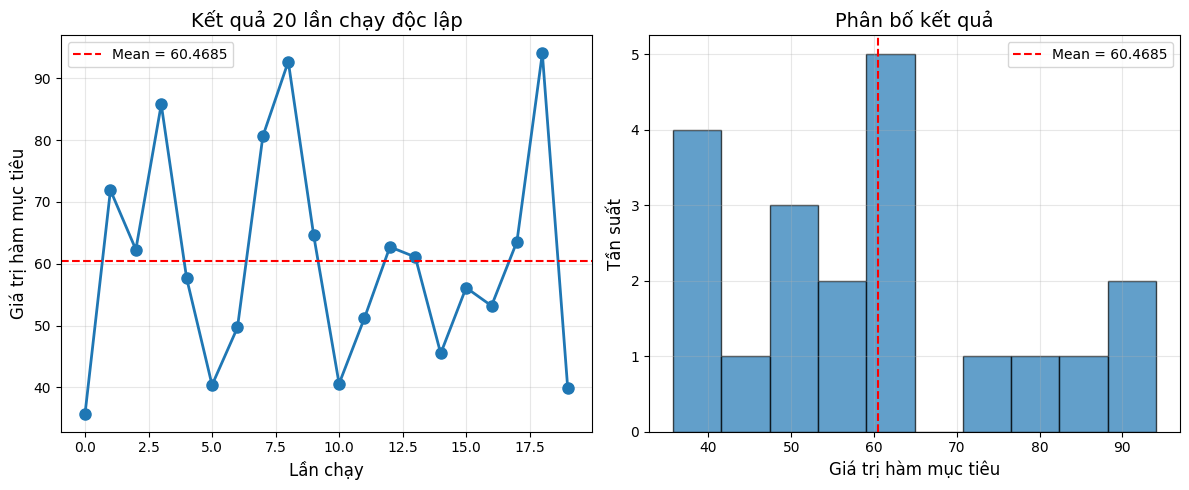

In [12]:
# Vẽ biểu đồ phân bố kết quả
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results, 'o-', linewidth=2, markersize=8)
plt.xlabel('Lần chạy', fontsize=12)
plt.ylabel('Giá trị hàm mục tiêu', fontsize=12)
plt.title('Kết quả 20 lần chạy độc lập', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean = {mean_value:.4f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(results, bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Giá trị hàm mục tiêu', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.title('Phân bố kết quả', fontsize=14)
plt.axvline(x=mean_value, color='r', linestyle='--', label=f'Mean = {mean_value:.4f}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()